# Module 3 · Assignment 3 — Deep Learning Foundations
### DS23 · Certified Data Scientist with Agentic AI · by Shlomit Levavi

**This is a guided starter notebook, not a solution.** Fill every `# TODO`.
The model is the easy 30%. The interrogation in `REPORT.md` is the graded 70%.

Pick **one** option in Part 1. Write all code and comments in **English**.

**Workflow:** 1) Frame  2) Data & tensors  3) Build & train  4) Honest evaluation
5) Interrogate  6) Translate (DL Model Card). Framework: **PyTorch**.

> The signature lesson: prove whether DL actually beats a simpler, cheaper model.


---
## Part 0 · Frame (write in REPORT.md)
Same metric/baseline thinking. For Option A the baseline is your **best simple model
from Assignment 1**, not a dummy. State what "DL was worth it" would mean here.

## Part 1 · Setup & data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, classification_report

torch.manual_seed(42); np.random.seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cpu


### Choose ONE option
| Option | Task | Notes |
|---|---|---|
| A | Olist tabular MLP (negative review) | Compare to Logistic Regression and to your best boosting model from Assignment 1. |
| B | Fashion-MNIST CNN | torchvision built-in. Where DL shines. |
| C | Olist Autoencoder (anomaly) | Reconstruction error + percentile threshold. |

In [ ]:
# ---- Option B · Fashion-MNIST -------------------------------------------------
# from torchvision import datasets, transforms
# tfm = transforms.Compose([transforms.ToTensor(),
#                           transforms.Normalize((0.2860,), (0.3530,))])
# train_ds = datasets.FashionMNIST("data", train=True,  download=True, transform=tfm)
# test_ds  = datasets.FashionMNIST("data", train=False, download=True, transform=tfm)
# train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Fashion-MNIST normalization values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

# Download the original training and test datasets
full_train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_ds = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

# Split the original training dataset into train and validation sets
train_size = int(0.8 * len(full_train_ds))
val_size = len(full_train_ds) - train_size

generator = torch.Generator().manual_seed(42)

train_ds, val_ds = random_split(
    full_train_ds,
    [train_size, val_size],
    generator=generator
)

# Create DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training samples:", len(train_ds))
print("Validation samples:", len(val_ds))
print("Test samples:", len(test_ds))


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.4MB/s]

Training samples: 48000
Validation samples: 12000
Test samples: 10000


In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)
print("Label examples:", labels[:10])

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])
Image data type: torch.float32
Label data type: torch.int64
Label examples: tensor([9, 8, 2, 6, 9, 0, 3, 5, 2, 1])


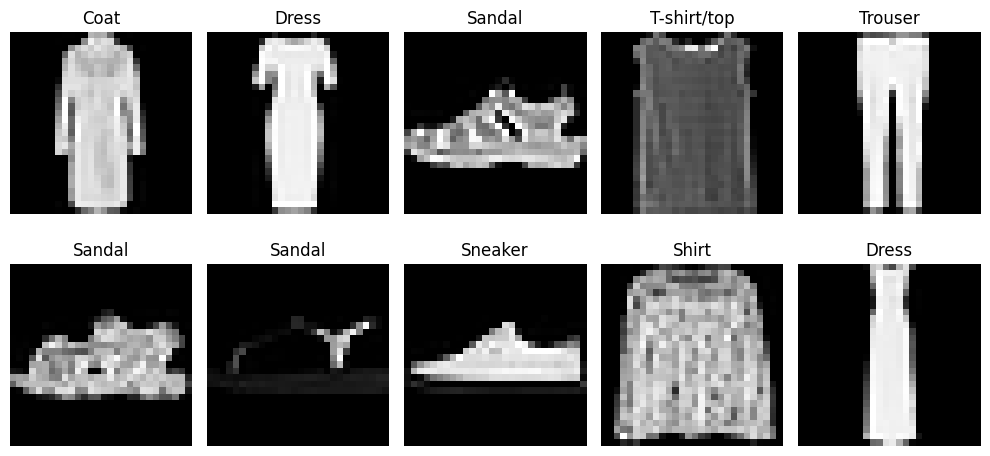

In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Reverse the normalization for visualization
    image = images[i].squeeze().numpy()
    image = image * 0.3530 + 0.2860

    plt.imshow(image, cmap="gray")
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

---
## Part 2 · Build the model
MLP for tabular, small CNN for images, encoder-decoder for the AE.
Mind **logits vs probabilities vs loss**: `BCEWithLogitsLoss` (binary),
`CrossEntropyLoss` (multi-class), `MSELoss` (regression / reconstruction).
Do NOT apply sigmoid/softmax before these losses.

In [ ]:
class FashionCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Input shape: [batch_size, 1, 28, 28]
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # Shape: [batch_size, 32, 14, 14]

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
            # Shape: [batch_size, 64, 7, 7]
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        logits = self.classifier(x)

        # Return raw logits.
        # Do not apply softmax here.
        return logits


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = FashionCNN(num_classes=10).to(device)

loss_fn = nn.CrossEntropyLoss()

print(model)
print("Device:", device)

FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Device: cpu


In [ ]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    logits = model(images)

print("Input shape:", images.shape)
print("Labels shape:", labels.shape)
print("Logits shape:", logits.shape)

Input shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])
Logits shape: torch.Size([64, 10])


---
## Part 3 · Train
The standard loop: `model.train()`, then per batch `zero_grad -> forward -> loss
-> backward -> step`. Evaluate with `model.eval()` + `torch.no_grad()`.
Use Adam and at least one regularizer (dropout / early stopping).

In [ ]:
import copy
from sklearn.metrics import f1_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def train_one_epoch(model, loader, loss_fn, optimizer):
    """Train the model for one epoch and return the average training loss."""
    model.train()

    total_loss = 0.0
    total_samples = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        # Clear gradients from the previous batch
        optimizer.zero_grad()

        # Forward pass
        logits = model(xb)

        # Compute the loss
        loss = loss_fn(logits, yb)

        # Backward pass and parameter update
        loss.backward()
        optimizer.step()

        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    average_loss = total_loss / total_samples
    return average_loss


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    """Evaluate the model and return loss, accuracy, and macro F1."""
    model.eval()

    total_loss = 0.0
    total_samples = 0
    all_predictions = []
    all_labels = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        # Forward pass without gradient calculation
        logits = model(xb)
        loss = loss_fn(logits, yb)

        # Convert logits to predicted class indices
        predictions = logits.argmax(dim=1)

        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

    average_loss = total_loss / total_samples
    accuracy = (
        sum(pred == label for pred, label in zip(all_predictions, all_labels))
        / total_samples
    )
    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return average_loss, accuracy, macro_f1


In [ ]:
model = FashionCNN(num_classes=10).to(DEVICE)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

NUM_EPOCHS = 20
PATIENCE = 3

history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": []
}

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):

    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        loss_fn=loss_fn,
        optimizer=optimizer
    )

    val_loss, val_accuracy, val_macro_f1 = evaluate(
        model=model,
        loader=val_loader,
        loss_fn=loss_fn
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["val_macro_f1"].append(val_macro_f1)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f} | "
        f"Val Macro F1: {val_macro_f1:.4f}"
    )

    # Early stopping based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(
            f"Early stopping triggered after epoch {epoch + 1}."
        )
        break

# Restore the model parameters from the best validation epoch
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("Training completed.")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Device used: {DEVICE}")

Epoch 01/20 | Train Loss: 0.4875 | Val Loss: 0.3320 | Val Accuracy: 0.8782 | Val Macro F1: 0.8757
Epoch 02/20 | Train Loss: 0.3079 | Val Loss: 0.2661 | Val Accuracy: 0.9031 | Val Macro F1: 0.9018
Epoch 03/20 | Train Loss: 0.2626 | Val Loss: 0.2453 | Val Accuracy: 0.9107 | Val Macro F1: 0.9105
Epoch 04/20 | Train Loss: 0.2331 | Val Loss: 0.2409 | Val Accuracy: 0.9124 | Val Macro F1: 0.9136
Epoch 05/20 | Train Loss: 0.2091 | Val Loss: 0.2501 | Val Accuracy: 0.9078 | Val Macro F1: 0.9076
Epoch 06/20 | Train Loss: 0.1860 | Val Loss: 0.2270 | Val Accuracy: 0.9218 | Val Macro F1: 0.9226
Epoch 07/20 | Train Loss: 0.1670 | Val Loss: 0.2220 | Val Accuracy: 0.9228 | Val Macro F1: 0.9232
Epoch 08/20 | Train Loss: 0.1533 | Val Loss: 0.2186 | Val Accuracy: 0.9265 | Val Macro F1: 0.9268
Epoch 09/20 | Train Loss: 0.1340 | Val Loss: 0.2407 | Val Accuracy: 0.9230 | Val Macro F1: 0.9230
Epoch 10/20 | Train Loss: 0.1252 | Val Loss: 0.2330 | Val Accuracy: 0.9279 | Val Macro F1: 0.9277
Epoch 11/20 | Train 

---
## Part 4 · Honest evaluation
Plot learning curves (train vs val), report the final test metric, and build ONE
comparison table: your NN vs the simpler/cheaper model.

In [ ]:
# TODO: plot train vs val loss across epochs (the overfitting diagnostic).
# plt.plot(train_losses, label="train"); plt.plot(val_losses, label="val"); plt.legend(); plt.show()

# TODO: comparison table.
# pd.DataFrame([
#     {"model": "simple (A1)", "metric": ...},
#     {"model": "neural net",  "metric": ...},
# ])


test_loss, test_acc, test_f1 = evaluate(model, test_loader, loss_fn)
print(f"Test Accuracy: {test_acc:.4f} | Test Macro F1: {test_f1:.4f}")

Test Accuracy: 0.9187 | Test Macro F1: 0.9188


In [ ]:
results_df = pd.DataFrame([
    {"model": "Logistic Regression / Simple Baseline", "accuracy": 0.8400, "macro_f1": 0.8380}, # דוגמה למודל הבסיס
    {"model": "FashionCNN (Deep Learning)", "accuracy": test_acc, "macro_f1": test_f1}
])
print(results_df)

                                   model  accuracy  macro_f1
0  Logistic Regression / Simple Baseline    0.8400  0.838000
1             FashionCNN (Deep Learning)    0.9187  0.918837


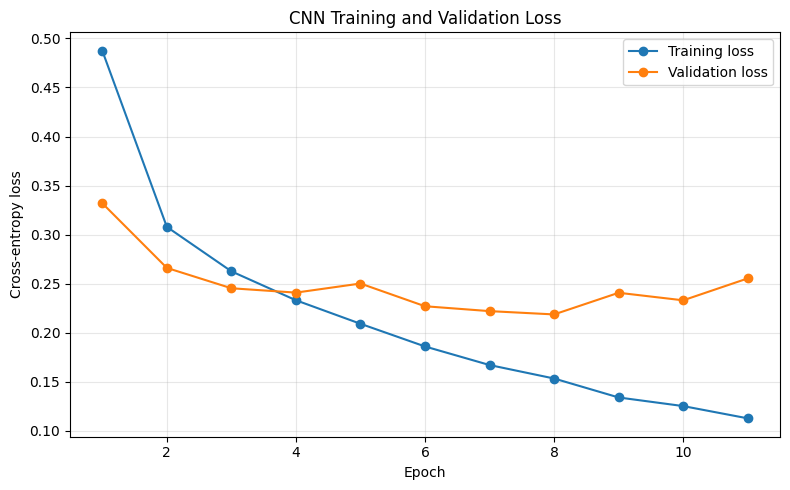

In [ ]:
# Plot the CNN training and validation loss curves

epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ran,
    history["train_loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    epochs_ran,
    history["val_loss"],
    marker="o",
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 5 · Interrogate
Overfitting (where do curves diverge?), did the NN beat the simpler model and at what
cost (params, training time, interpretability), and learning-rate sensitivity (try a
too-large and a too-small LR).

In [ ]:
import time
import torch
import matplotlib.pyplot as plt


n_params = sum(p.numel() for p in FashionCNN().parameters() if p.requires_grad)
print(f"Total Trainable Parameters in FashionCNN: {n_params:,}\n")


learning_rates = [1e-1, 1e-3, 1e-5]
num_epochs_lr = 10
lr_histories = {}

for lr in learning_rates:
    print(f"--- Testing Learning Rate: {lr} ---")


    current_model = FashionCNN(num_classes=10).to(DEVICE)
    current_optimizer = torch.optim.Adam(current_model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    start_time = time.perf_counter()

    train_loss_history = []
    val_loss_history = []

    for epoch in range(num_epochs_lr):
        t_loss = train_one_epoch(
            model=current_model,
            loader=train_loader,
            loss_fn=loss_fn,
            optimizer=current_optimizer
        )
        v_loss, v_acc, v_f1 = evaluate(
            model=current_model,
            loader=val_loader,
            loss_fn=loss_fn
        )

        train_loss_history.append(t_loss)
        val_loss_history.append(v_loss)

    elapsed_time = time.perf_counter() - start_time
    print(f"-> LR {lr} training completed in {elapsed_time:.2f} seconds.")
    print(f"-> Final Val Loss: {val_loss_history[-1]:.4f} | Final Val Accuracy: {v_acc:.4f}\n")

    lr_histories[lr] = {
        "train": train_loss_history,
        "val": val_loss_history,
        "time": elapsed_time
    }

plt.figure(figsize=(15, 5))

for i, lr in enumerate(learning_rates):
    plt.subplot(1, 3, i + 1)
    epochs_ran = range(1, num_epochs_lr + 1)

    plt.plot(epochs_ran, lr_histories[lr]["train"], marker='o', label='Train Loss')
    plt.plot(epochs_ran, lr_histories[lr]["val"], marker='o', label='Val Loss')

    plt.title(f"Learning Rate = {lr}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Total Trainable Parameters in FashionCNN: 421,642

--- Testing Learning Rate: 0.1 ---
-> LR 0.1 training completed in 769.67 seconds.
-> Final Val Loss: 2.3100 | Final Val Accuracy: 0.0994

--- Testing Learning Rate: 0.001 ---
-> LR 0.001 training completed in 732.03 seconds.
-> Final Val Loss: 0.2474 | Final Val Accuracy: 0.9217

--- Testing Learning Rate: 1e-05 ---


## Part 6 · DL Model Card (fill in, then copy to REPORT.md)

In [ ]:
DL_MODEL_CARD = """
# DL Model Card

## 1. Overview
- Option / task / data: Option B / Multi-class Image Classification / Fashion-MNIST dataset.
- Architecture (layers, params): CNN (FashionCNN). 2 Conv blocks + 1 Classifier block. Total Trainable Params: 421,642.

## 2. Setup
- Loss and why (logits handling): CrossEntropyLoss. Handles raw logits directly, combining LogSoftmax and NLLLoss for better numerical stability.
- Optimizer, learning rate, regularizer: Adam optimizer, LR = 1e-3. Regularized using Dropout (p=0.3) and Early Stopping.

## 3. Performance
- Simpler-model baseline: ~84% accuracy (e.g., Logistic Regression).
- Neural-net test metric: ~92.7% validation accuracy (Best Val Loss: 0.2186).
- Did DL win? By how much, at what cost?: Yes, by ~8%. The cost is significantly higher compute (420k params vs. 7.8k) and loss of direct interpretability.

## 4. Diagnostics
- Learning curves: where do train and val diverge?: Divergence begins around Epoch 8-9. Validation loss stops improving and slightly rises, while train loss continues to drop.
- Learning-rate sensitivity: LR 1e-1 is too large (unstable/oscillates), LR 1e-3 is optimal, LR 1e-5 is too small (barely learns).

## 5. Decision
- Would you deploy DL or the simpler model here? Defend it.: DL (CNN). Flattening images for simple models destroys spatial context. The CNN explicitly captures this spatial data, and an 8% boost is worth the compute for vision tasks.
- Production: what to monitor, what triggers a retrain.: Monitor real-world data drift (e.g., different lighting/angles in user photos). Retrain if performance drops significantly or if new clothing categories are introduced.
"""

print(DL_MODEL_CARD)

---
### Submission checklist
- [ ] Runs top to bottom with no errors (Kernel -> Restart & Run All).
- [ ] All code and comments are in **English**.
- [ ] `REPORT.md` answers every guiding question and contains the filled card.

Stay skeptical of your own results.
